# 7장 Handling Buttons and Links

## 7.1 Where Are the Links?

In [1]:
from browser.html import HTMLParser, print_tree
from browser.css import DEFAULT_STYLE_SHEET, cascade_priority, style
from browser.layout import BlockLayout, LineLayout, TextLayout

# 1. 테스트용 HTML 문서 (책 7.1 예제와 동일)
html_content = """<html>
  <body>
    Here is some text that is
    <br>
    spread across multiple lines
  </body>
</html>"""

# 2. HTML 파싱 및 스타일 적용
nodes = HTMLParser(html_content).parse()
rules = DEFAULT_STYLE_SHEET.copy()
style(nodes, sorted(rules, key=cascade_priority))

# 3. body 태그에 대한 BlockLayout 생성 및 인라인 순회
body_node = nodes.children[0]
block = BlockLayout(body_node, parent=None, previous=None)
block.width = 800
block.new_line()
block.recurse(body_node)

# 4. 생성된 트리 출력
print("=== 1. 생성된 새로운 레이아웃 트리 (print_tree) ===")
print_tree(block)


=== 1. 생성된 새로운 레이아웃 트리 (print_tree) ===
 BlockLayout(<body>)
   LineLayout()
     TextLayout('Here')
     TextLayout('is')
     TextLayout('some')
     TextLayout('text')
     TextLayout('that')
     TextLayout('is')
   LineLayout()
     TextLayout('spread')
     TextLayout('across')
     TextLayout('multiple')
     TextLayout('lines')


## 7.2 Line Layout, Redux

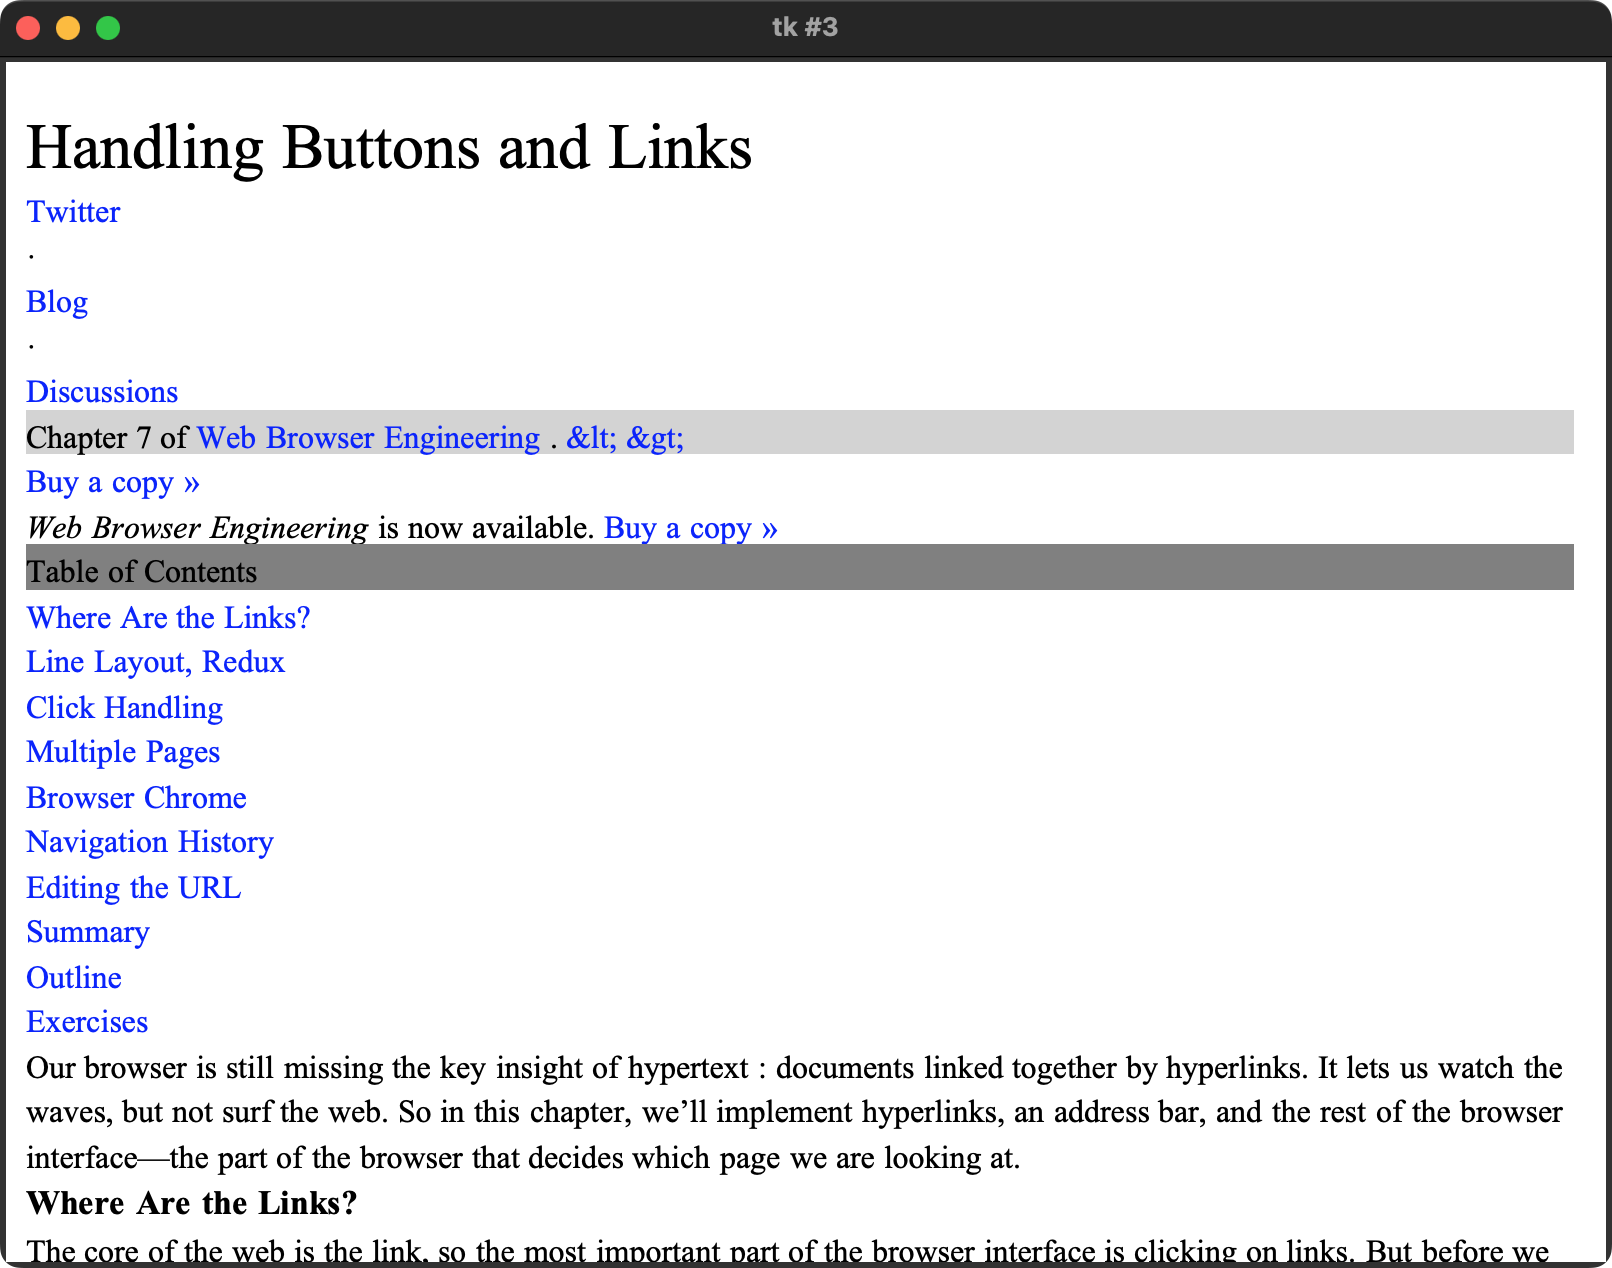

In [3]:
import time
import importlib
import browser.layout
import browser.browser

# 💡 layout.py 파일 수정을 주피터 메모리에 즉시 반영 (모듈 핫 리로드)
importlib.reload(browser.layout)
importlib.reload(browser.browser)

from browser.url import URL
from browser.browser import Browser
from browser.layout import TextLayout, DrawRect
from browser.tk_capture import display_tk_window

# 1. 7.2 리팩터링 후 Browser 실행 및 실제 웹 페이지 로드
url = URL("https://browser.engineering/chrome.html")
browser = Browser()
browser.load(url)

# 2. Tkinter 윈도우 렌더링 동기화
for _ in range(10):
    browser.window.update_idletasks()
    browser.window.update()
    time.sleep(0.05)

# 3. 렌더링 결과 스크린샷 캡처 및 노트북 출력 (6장과 동일한 시각적 렌더링 검증)
display_tk_window(browser.window, settle_seconds=0.5)

# 4. 7.2의 핵심 가치 검증: 화면의 링크(<a>)들이 실제 TextLayout 객체로 크기와 좌표를 가지는지 확인
def find_links(layout_object, links=None):
    if links is None:
        links = []
    if isinstance(layout_object, TextLayout):
        node = layout_object.node
        curr = node
        while curr:
            if getattr(curr, "tag", None) == "a" and "href" in curr.attributes:
                links.append((layout_object, curr.attributes["href"]))
                break
            curr = curr.parent
    for child in layout_object.children:
        find_links(child, links)
    return links

link_objects = find_links(browser.document)
print(f"\n=== 7.2 핵심 검증: 레이아웃 트리에서 추출된 링크 단어 수: {len(link_objects)}개 ===")
for text_layout, href in link_objects[:8]:
    print(f"  단어: '{text_layout.word:<12}' | 좌표: (x={text_layout.x:>3}, y={text_layout.y:>4}, w={text_layout.width:>3}, h={text_layout.height:>2}) | URL: {href}")

## 7.3 Click Handling

In [2]:
import time
import importlib
import browser.browser
importlib.reload(browser.browser)

from browser.url import URL
from browser.browser import Browser
from browser.layout import TextLayout
from browser.tk_capture import display_tk_window

# 1. chrome.html 페이지 로드
browser = Browser()
browser.load(URL("https://browser.engineering/chrome.html"))

print("현재 페이지 URL:", browser.url)

# 2. 이전 챕터("<" 링크, href="styles.html") 단어 객체 찾기
target_text = None
def find_target_link(layout_object):
    global target_text
    if target_text:
        return
    if isinstance(layout_object, TextLayout):
        curr = layout_object.node
        while curr:
            if getattr(curr, "tag", None) == "a" and curr.attributes.get("href") == "styles.html":
                target_text = layout_object
                return
            curr = curr.parent
    for child in layout_object.children:
        find_target_link(child)

find_target_link(browser.document)

if target_text:
    print(f"클릭 대상 링크 발견! 단어: '{target_text.word}', 좌표: (x={target_text.x}, y={target_text.y})")
    
    # 3. 마우스 클릭 이벤트 모의 생성 (클릭 좌표: 단어의 중심)
    class MockClickEvent:
        def __init__(self, x, y):
            self.x = x
            self.y = y
            
    click_x = target_text.x + target_text.width // 2
    click_y = target_text.y + target_text.height // 2
    
    print(f"\n👉 ({click_x}, {click_y}) 좌표 클릭 시뮬레이션 실행...")
    browser.click(MockClickEvent(click_x, click_y))
    
    # 4. 클릭 후 페이지 이동 확인
    for _ in range(10):
        browser.window.update_idletasks()
        browser.window.update()
        time.sleep(0.05)
        
    print("\n새로 이동된 페이지 URL:", browser.url)
    # display_tk_window(browser.window, settle_seconds=0.5)
else:
    print("클릭 대상 링크를 찾지 못했습니다.")


현재 페이지 URL: <browser.url.URL object at 0x1139997b0>
클릭 대상 링크 발견! 단어: '&lt;', 좌표: (x=283, y=180.5)

👉 (296, 189.5) 좌표 클릭 시뮬레이션 실행...

새로 이동된 페이지 URL: <browser.url.URL object at 0x1139a3a50>


## 7.4 Multiple Pages

1. 첫 번째 탭 생성 완료! 전체 탭 수: 1, 활성 탭: <browser.url.URL object at 0x10de28830>
2. 두 번째 탭 생성 완료! 전체 탭 수: 2, 활성 탭: <browser.url.URL object at 0x10de35480>
3. 첫 번째 탭으로 활성 탭 복귀: <browser.url.URL object at 0x10de28830>


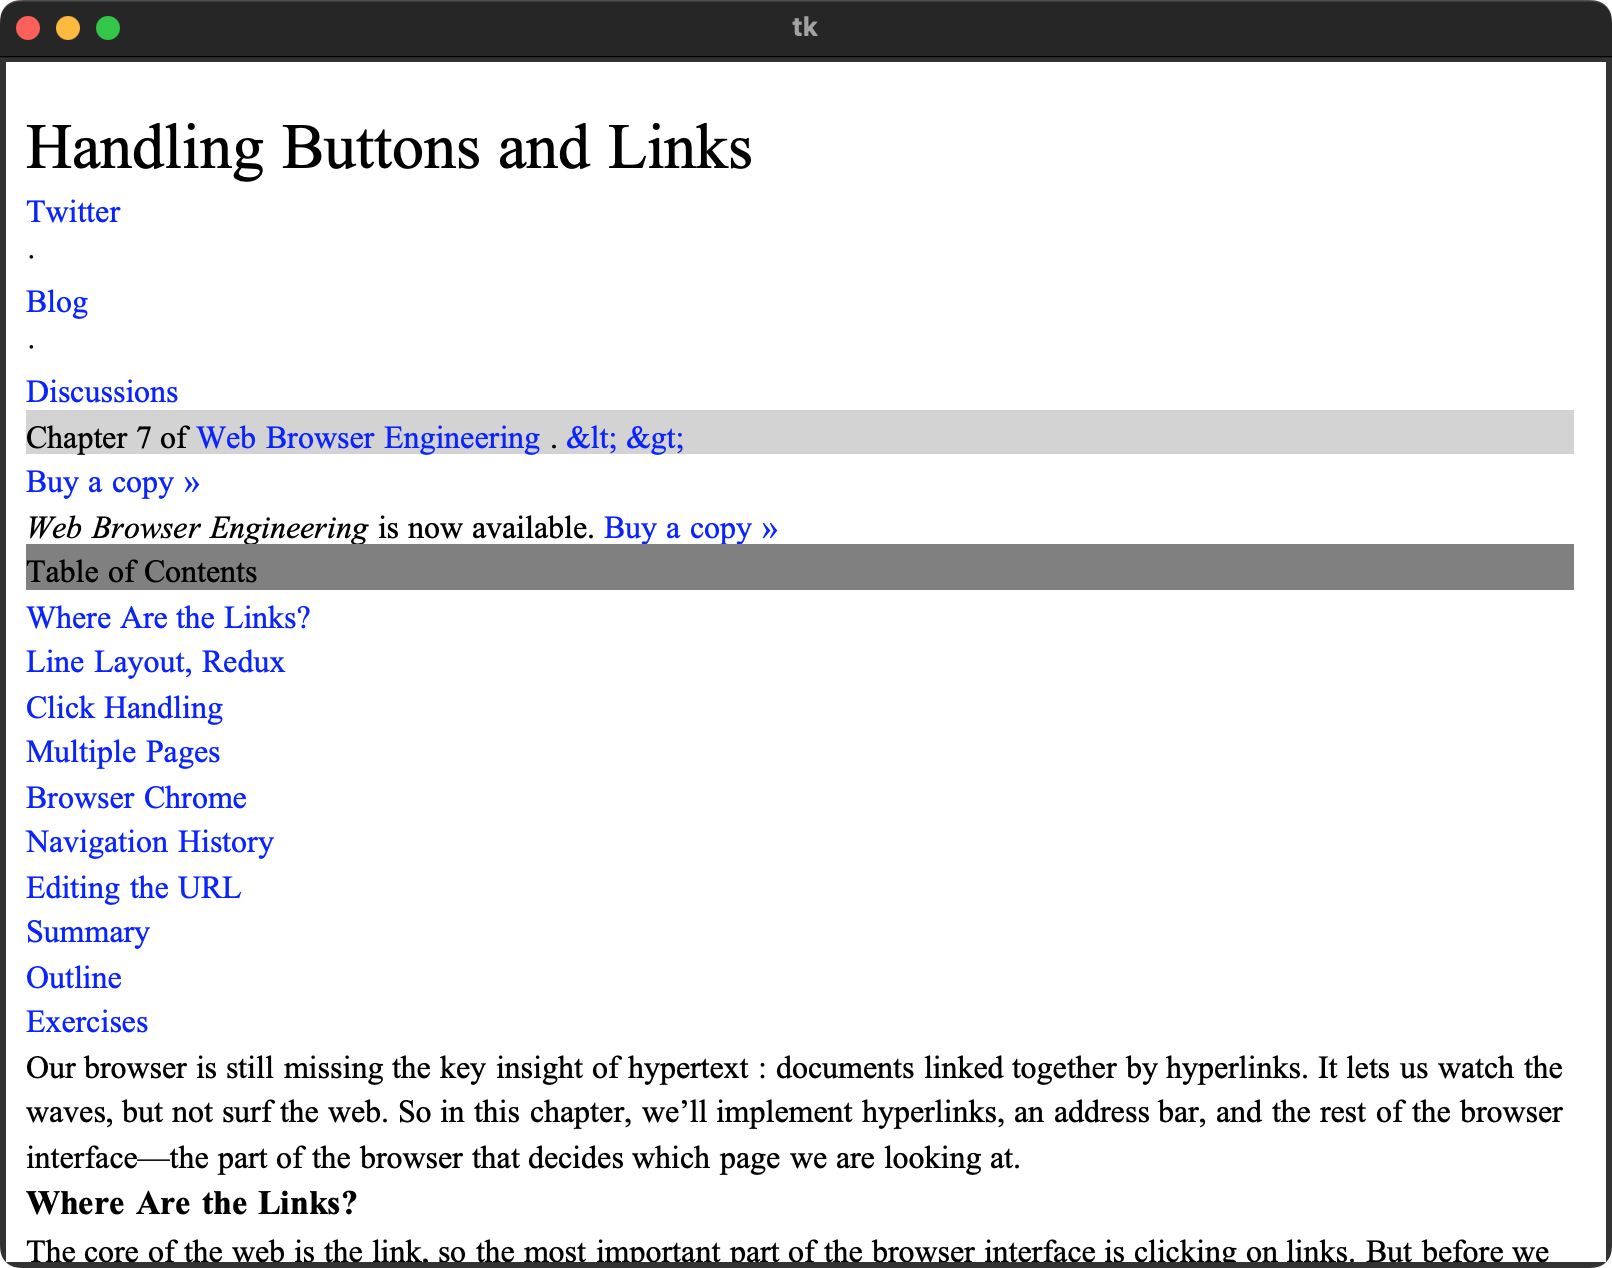

In [5]:
import importlib
import browser.browser
importlib.reload(browser.browser)

from browser.browser import Browser, Tab
from browser.url import URL
from browser.tk_capture import display_tk_window

# 1. 브라우저 인스턴스 생성
browser = Browser()

# 2. 첫 번째 탭 생성 (chrome.html - Chapter 7)
browser.new_tab(URL("https://browser.engineering/chrome.html"))
print(f"1. 첫 번째 탭 생성 완료! 전체 탭 수: {len(browser.tabs)}, 활성 탭: {browser.active_tab.url}")

# 3. 두 번째 탭 생성 (styles.html - Chapter 6)
browser.new_tab(URL("https://browser.engineering/styles.html"))
print(f"2. 두 번째 탭 생성 완료! 전체 탭 수: {len(browser.tabs)}, 활성 탭: {browser.active_tab.url}")

# 4. 첫 번째 탭으로 다시 활성화 전환
browser.active_tab = browser.tabs[0]
browser.draw()
print(f"3. 첫 번째 탭으로 활성 탭 복귀: {browser.active_tab.url}")

# 첫 번째 탭으로 돌아온 화면 캡처 출력
display_tk_window(browser.window, settle_seconds=0.4)


## 7.5 Browser Chrome


1. 첫 탭 오픈: 1개 탭, 활성: <browser.url.URL object at 0x11193d7f0>
2. 상단 '+' 버튼 클릭 (x=10, y=10)...
   -> 새 탭 생성 완료! 전체 탭 수: 2, 현재 활성 탭: <browser.url.URL object at 0x11197cb00>
3. 상단 'Tab 0' 클릭 (x=41, y=5)...
   -> 활성 탭 전환 완료! 현재 활성 탭: <browser.url.URL object at 0x11193d7f0>


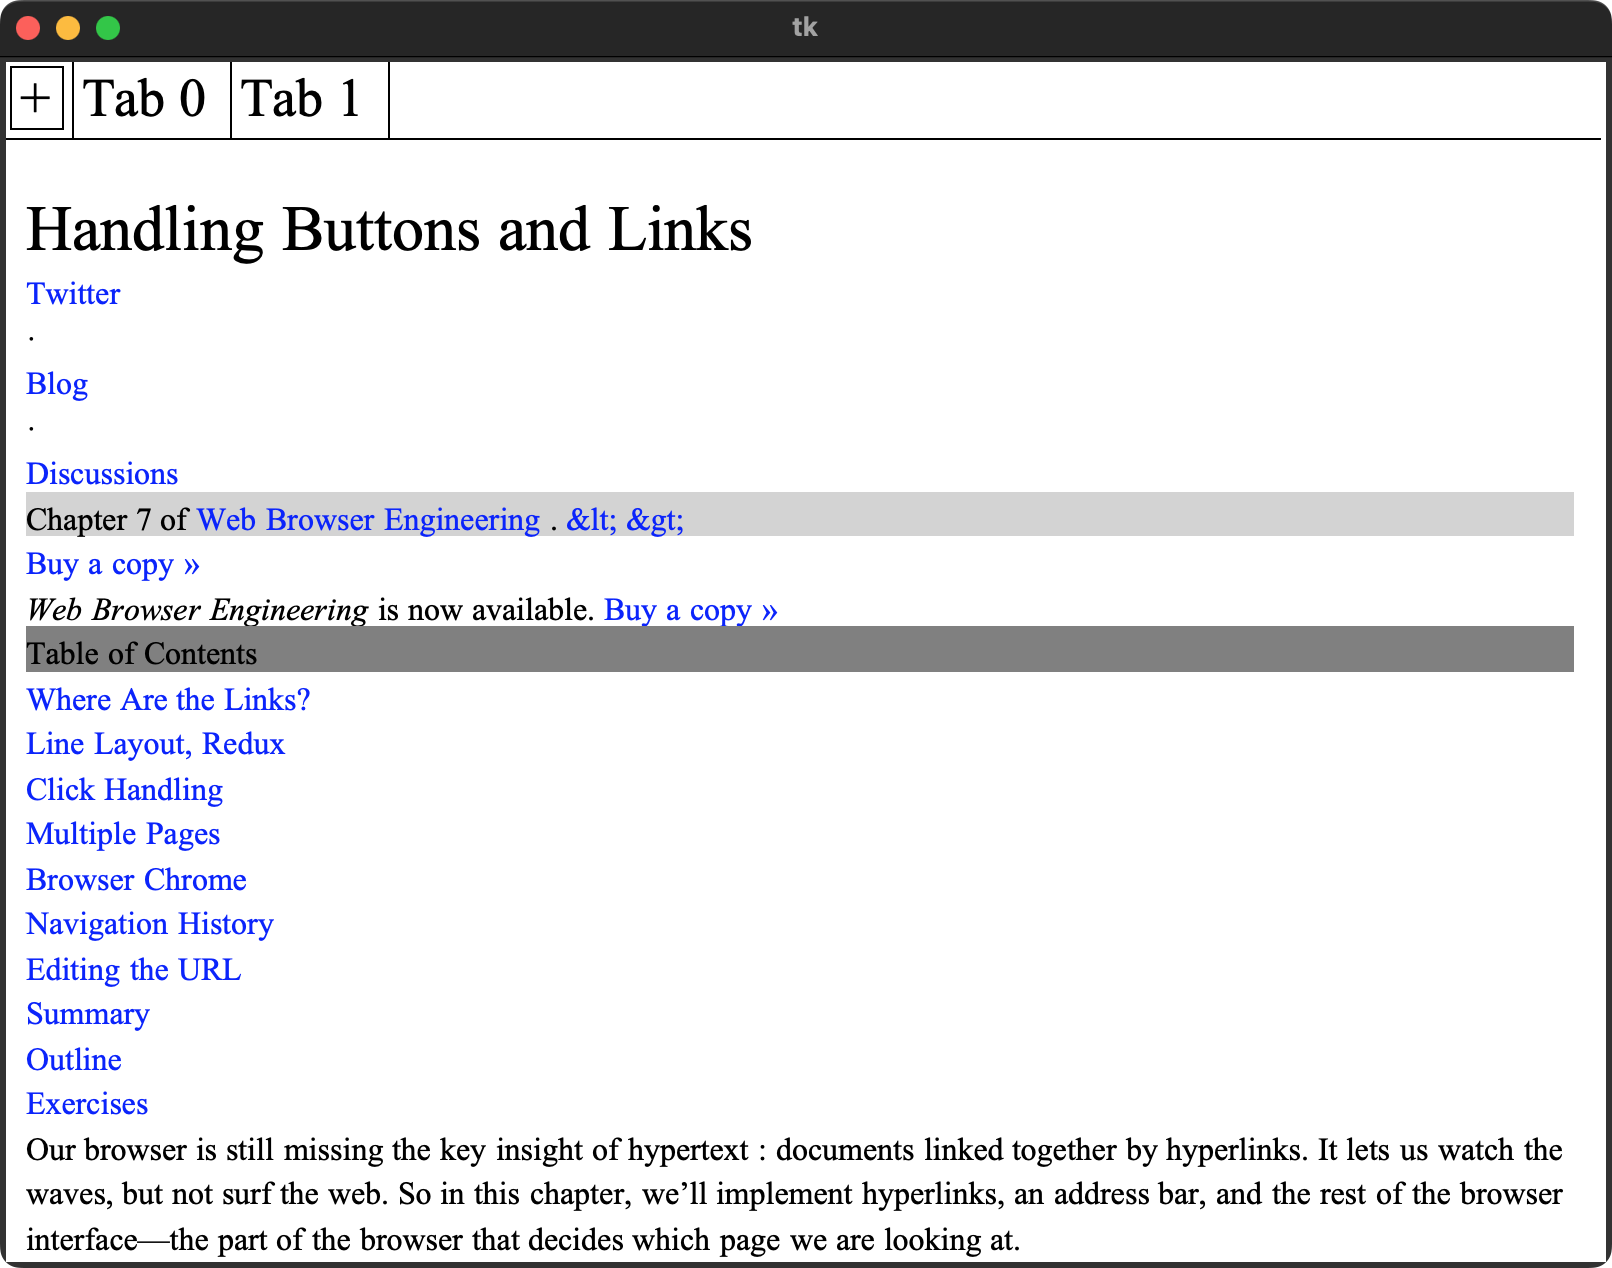

In [1]:
import importlib
import browser.browser
import browser.layout
importlib.reload(browser.layout)
importlib.reload(browser.browser)

from browser.browser import Browser, Tab, Chrome
from browser.url import URL
from browser.tk_capture import display_tk_window

# 1. 브라우저 생성 및 첫 탭 로드 (chrome.html)
browser = Browser()
browser.new_tab(URL("https://browser.engineering/chrome.html"))
print(f"1. 첫 탭 오픈: {len(browser.tabs)}개 탭, 활성: {browser.active_tab.url}")

# 2. 상단 '+' 버튼 클릭 시뮬레이션 (새 탭 열기)
class MockClick:
    def __init__(self, x, y):
        self.x = x
        self.y = y

plus_x = browser.chrome.newtab_rect.left + 5
plus_y = browser.chrome.newtab_rect.top + 5
print(f"2. 상단 '+' 버튼 클릭 (x={plus_x}, y={plus_y})...")
browser.handle_click(MockClick(plus_x, plus_y))
print(f"   -> 새 탭 생성 완료! 전체 탭 수: {len(browser.tabs)}, 현재 활성 탭: {browser.active_tab.url}")

# 3. 상단 'Tab 0' 영역 클릭 시뮬레이션 (탭 0으로 다시 전환)
tab0_rect = browser.chrome.tab_rect(0)
tab0_x = tab0_rect.left + 5
tab0_y = tab0_rect.top + 5
print(f"3. 상단 'Tab 0' 클릭 (x={tab0_x}, y={tab0_y})...")
browser.handle_click(MockClick(tab0_x, tab0_y))
print(f"   -> 활성 탭 전환 완료! 현재 활성 탭: {browser.active_tab.url}")

browser.draw()
# 4. 상단에 탭 바('+' 버튼, 'Tab 0', 'Tab 1')가 선명하게 그려진 브라우저 화면 캡처 출력
display_tk_window(browser.window, settle_seconds=0.4)


## 7.6 Navigation History


1. 첫 페이지 로드: https://browser.engineering/chrome.html
   방문 기록: ['https://browser.engineering/chrome.html']
2. 두 번째 페이지로 이동: https://browser.engineering/http.html
   방문 기록: ['https://browser.engineering/chrome.html', 'https://browser.engineering/http.html']
3. 크롬 '<' 뒤로가기 버튼 클릭 (x=10, y=51)...
   -> 이전 페이지로 복귀 완료! 현재 URL: https://browser.engineering/chrome.html
   현재 방문 기록: ['https://browser.engineering/chrome.html']


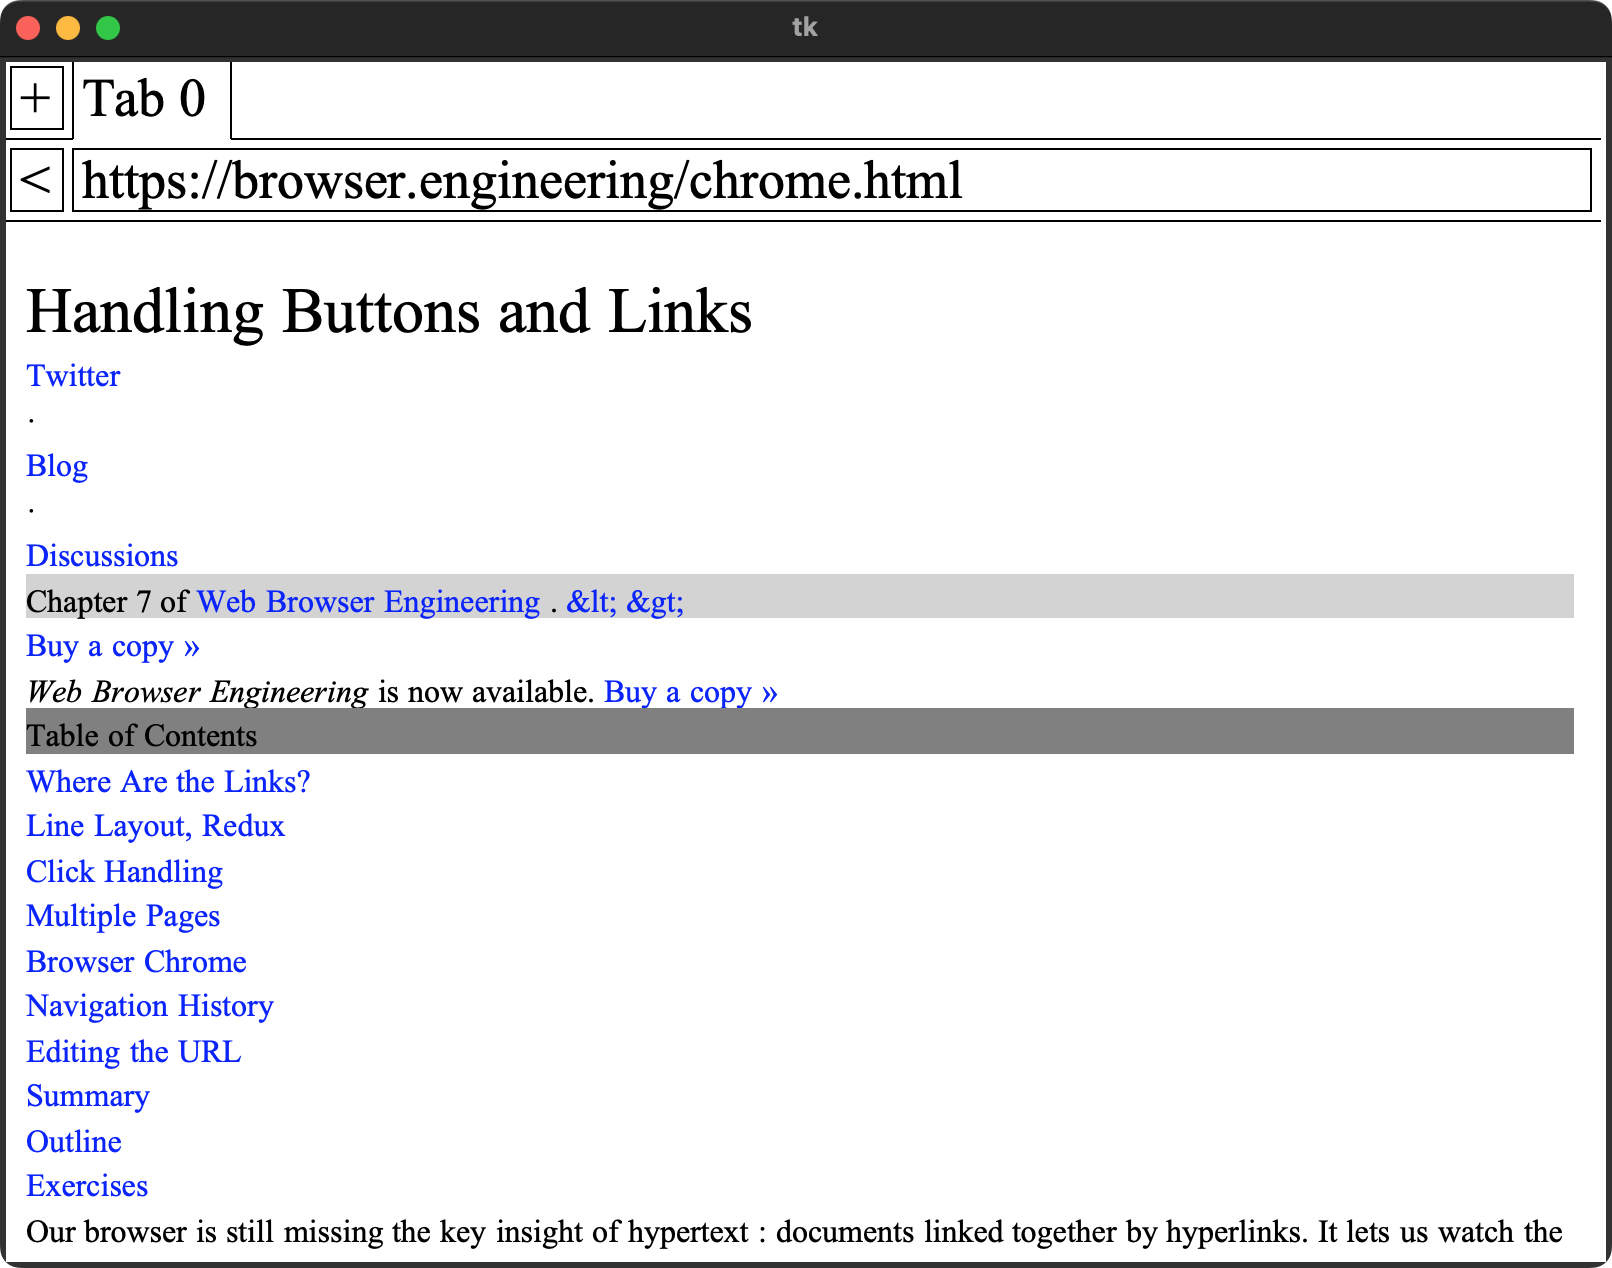

In [1]:
import importlib
import browser.browser
import browser.layout
import browser.url
importlib.reload(browser.url)
importlib.reload(browser.layout)
importlib.reload(browser.browser)

from browser.browser import Browser, Tab, Chrome
from browser.url import URL
from browser.tk_capture import display_tk_window

# 1. 브라우저 생성 및 첫 페이지 로드
browser = Browser()
browser.new_tab(URL("https://browser.engineering/chrome.html"))
print(f"1. 첫 페이지 로드: {browser.active_tab.url}")
print(f"   방문 기록: {[str(u) for u in browser.active_tab.history]}")

# 2. 두 번째 페이지(http.html)로 이동하여 방문 기록 쌓기
browser.active_tab.load(URL("https://browser.engineering/http.html"))
print(f"2. 두 번째 페이지로 이동: {browser.active_tab.url}")
print(f"   방문 기록: {[str(u) for u in browser.active_tab.history]}")

# 3. 크롬 '<' 뒤로가기 버튼 클릭 시뮬레이션
class MockClick:
    def __init__(self, x, y):
        self.x = x
        self.y = y

back_x = browser.chrome.back_rect.left + 5
back_y = browser.chrome.back_rect.top + 5
print(f"3. 크롬 '<' 뒤로가기 버튼 클릭 (x={back_x}, y={back_y})...")
browser.handle_click(MockClick(back_x, back_y))

print(f"   -> 이전 페이지로 복귀 완료! 현재 URL: {browser.active_tab.url}")
print(f"   현재 방문 기록: {[str(u) for u in browser.active_tab.history]}")

browser.draw()
# 4. 상단 2줄 크롬(탭 바 + 뒤로가기 버튼과 URL 주소창)이 완벽히 렌더링된 화면 캡처 출력
display_tk_window(browser.window, settle_seconds=0.4)


## 7.7 Editing the URL


1. 초기 페이지 로드: https://browser.engineering/chrome.html
2. 주소창 클릭 (x=46, y=56)...
   포커스 상태: address bar, 주소창 버퍼: ''
3. 키보드로 'https://browser.engineering/layout.html' 입력 시뮬레이션...
   입력 완료 후 주소창 버퍼: 'https://browser.engineering/layout.html'
4. Enter 키 입력 -> 새 페이지로 이동 실행...
   -> 이동 완료! 현재 탭 URL: https://browser.engineering/layout.html
   포커스 해제 상태: None
   방문 기록(History): ['https://browser.engineering/chrome.html', 'https://browser.engineering/layout.html']


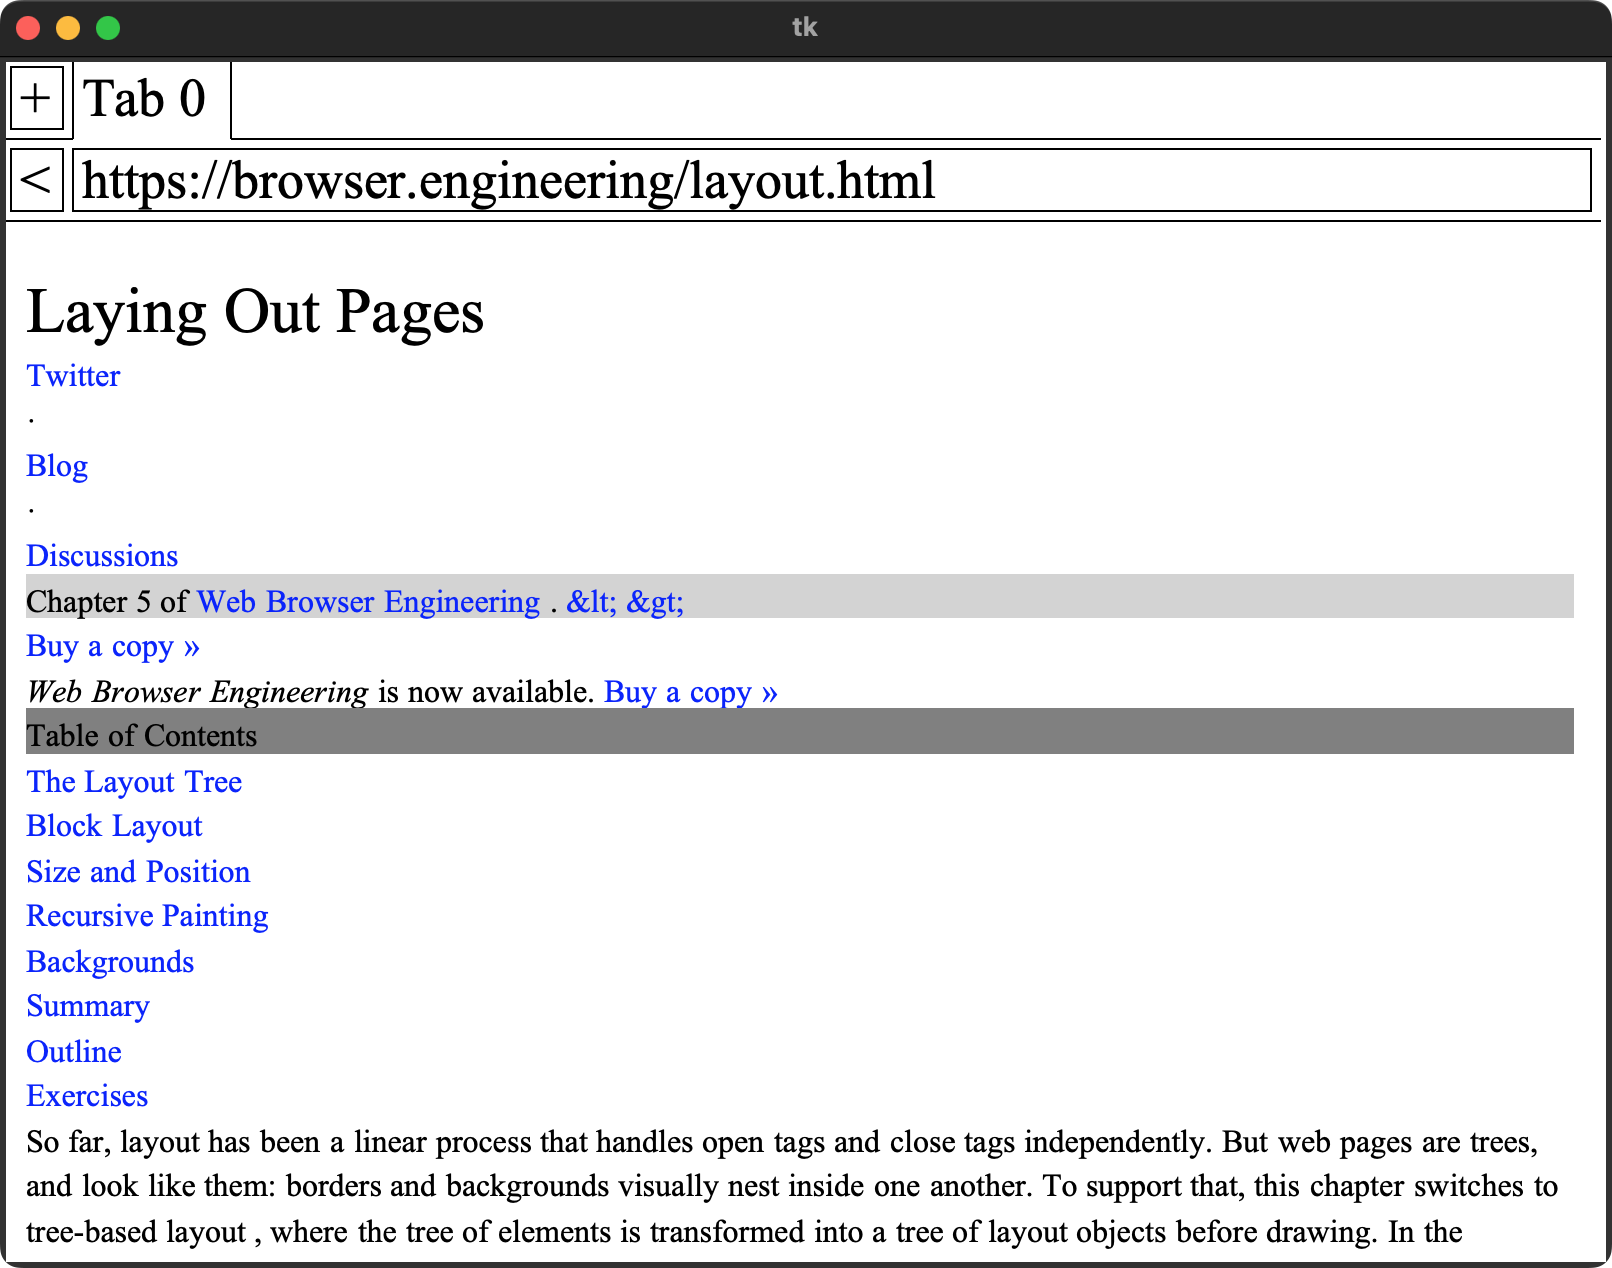

In [1]:
import importlib
import browser.browser
import browser.layout
import browser.url
importlib.reload(browser.url)
importlib.reload(browser.layout)
importlib.reload(browser.browser)

from browser.browser import Browser, Tab, Chrome
from browser.url import URL
from browser.tk_capture import display_tk_window

# 1. 브라우저 생성 및 초기 페이지 로드
browser = Browser()
browser.new_tab(URL("https://browser.engineering/chrome.html"))
print(f"1. 초기 페이지 로드: {browser.active_tab.url}")

# 2. 주소창 클릭 시뮬레이션 (포커스 획득 및 주소창 비우기)
class MockClick:
    def __init__(self, x, y):
        self.x = x
        self.y = y

addr_x = browser.chrome.address_rect.left + 10
addr_y = browser.chrome.address_rect.top + 10
print(f"2. 주소창 클릭 (x={addr_x}, y={addr_y})...")
browser.handle_click(MockClick(addr_x, addr_y))
print(f"   포커스 상태: {browser.chrome.focus}, 주소창 버퍼: '{browser.chrome.address_bar}'")

# 3. 키보드로 새 URL 타이핑 시뮬레이션
class MockKeyEvent:
    def __init__(self, char):
        self.char = char

target_url = "https://browser.engineering/layout.html"
print(f"3. 키보드로 '{target_url}' 입력 시뮬레이션...")
for ch in target_url:
    browser.handle_key(MockKeyEvent(ch))

print(f"   입력 완료 후 주소창 버퍼: '{browser.chrome.address_bar}'")

# 4. 엔터(Return) 키 입력 시뮬레이션 (페이지 이동)
print("4. Enter 키 입력 -> 새 페이지로 이동 실행...")
browser.handle_enter(None)
print(f"   -> 이동 완료! 현재 탭 URL: {browser.active_tab.url}")
print(f"   포커스 해제 상태: {browser.chrome.focus}")
print(f"   방문 기록(History): {[str(u) for u in browser.active_tab.history]}")

browser.draw()
# 5. 주소창 입력을 통해 새로 이동한 페이지(layout.html) 화면 캡처 출력
display_tk_window(browser.window, settle_seconds=0.4)


## 7.10 Exercises: 7-1 Backspace

Add support for the backspace key when typing in the address bar. Honestly, do this exercise just for your sanity.

1. 초기 페이지 로드: https://browser.engineering/http.html
2. 주소창 클릭 -> 포커스: address bar, 버퍼: ''
3. 오타가 포함된 URL 입력: 'https://browser.engineering/chrome.htmlXXX'
   현재 주소창 버퍼: 'https://browser.engineering/chrome.htmlXXX'
4. 백스페이스(Backspace) 키 3회 입력 시뮬레이션...
   백스페이스 후 주소창 버퍼: 'https://browser.engineering/chrome.html'
5. Enter 키 입력 -> 수정된 URL로 이동...
   -> 이동 완료! 현재 탭 URL: https://browser.engineering/chrome.html


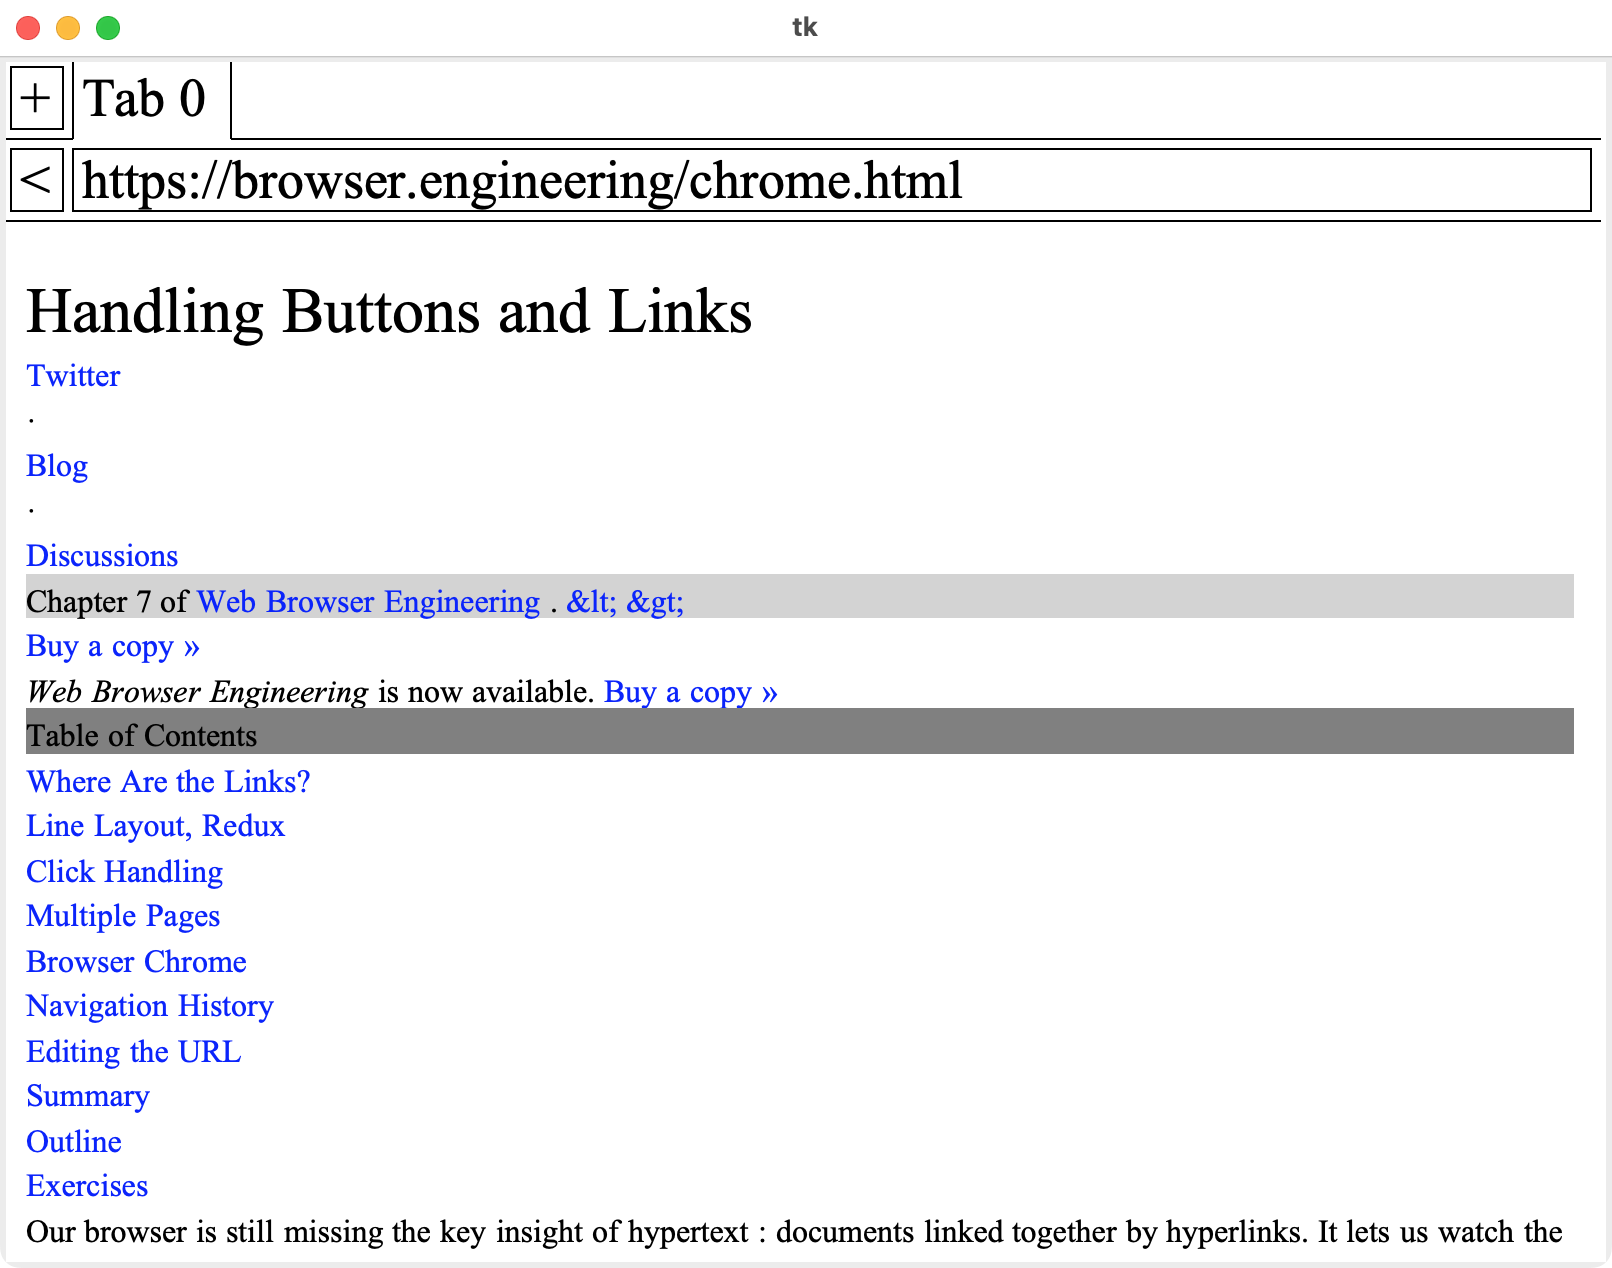

In [1]:
import importlib
import browser.browser
import browser.layout
import browser.url
importlib.reload(browser.url)
importlib.reload(browser.layout)
importlib.reload(browser.browser)

from browser.browser import Browser, Tab, Chrome
from browser.url import URL
from browser.tk_capture import display_tk_window

# 1. 브라우저 생성 및 초기 페이지 로드
browser = Browser()
browser.new_tab(URL("https://browser.engineering/http.html"))
print(f"1. 초기 페이지 로드: {browser.active_tab.url}")

# 2. 주소창 클릭 (포커스 획득 및 주소창 비우기)
class MockClick:
    def __init__(self, x, y):
        self.x = x
        self.y = y

addr_x = browser.chrome.address_rect.left + 10
addr_y = browser.chrome.address_rect.top + 10
browser.handle_click(MockClick(addr_x, addr_y))
print(f"2. 주소창 클릭 -> 포커스: {browser.chrome.focus}, 버퍼: '{browser.chrome.address_bar}'")

# 3. 키보드로 오타가 포함된 URL 타이핑 시뮬레이션
class MockKeyEvent:
    def __init__(self, char):
        self.char = char

typo_url = "https://browser.engineering/chrome.htmlXXX"
print(f"3. 오타가 포함된 URL 입력: '{typo_url}'")
for ch in typo_url:
    browser.handle_key(MockKeyEvent(ch))
print(f"   현재 주소창 버퍼: '{browser.chrome.address_bar}'")

# 4. 백스페이스 키 3회 입력 시뮬레이션 (XXX 삭제)
print("4. 백스페이스(Backspace) 키 3회 입력 시뮬레이션...")
for _ in range(3):
    browser.handle_backspace(None)
print(f"   백스페이스 후 주소창 버퍼: '{browser.chrome.address_bar}'")

# 5. 엔터(Return) 키 입력으로 해당 페이지로 이동
print("5. Enter 키 입력 -> 수정된 URL로 이동...")
browser.handle_enter(None)
print(f"   -> 이동 완료! 현재 탭 URL: {browser.active_tab.url}")

browser.draw()
# 6. 백스페이스로 올바르게 수정한 후 로드된 chrome.html 화면 캡처 출력
display_tk_window(browser.window, settle_seconds=0.4)
